# 1. Carga y Exploración de Datos
En esta sección importamos las librerías necesarias y cargamos el dataset de diabetes de Scikit-Learn.
Transformamos los datos a un DataFrame de Pandas para facilitar su manipulación.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes

# Cargar el dataset
diabetes = load_diabetes()

# Crear el DataFrame
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Añadir la variable objetivo (target)
df['target'] = diabetes.target

# Mostrar las dimensiones y las primeras filas
print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


# Análisis Estadístico y Correlaciones
Observamos los estadísticos descriptivos para entender la distribución de los datos.
Posteriormente, generamos una matriz de correlación para identificar qué variables están más relacionadas con la progresión de la enfermedad (`target`).

                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.293722e-17  1.130318e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.

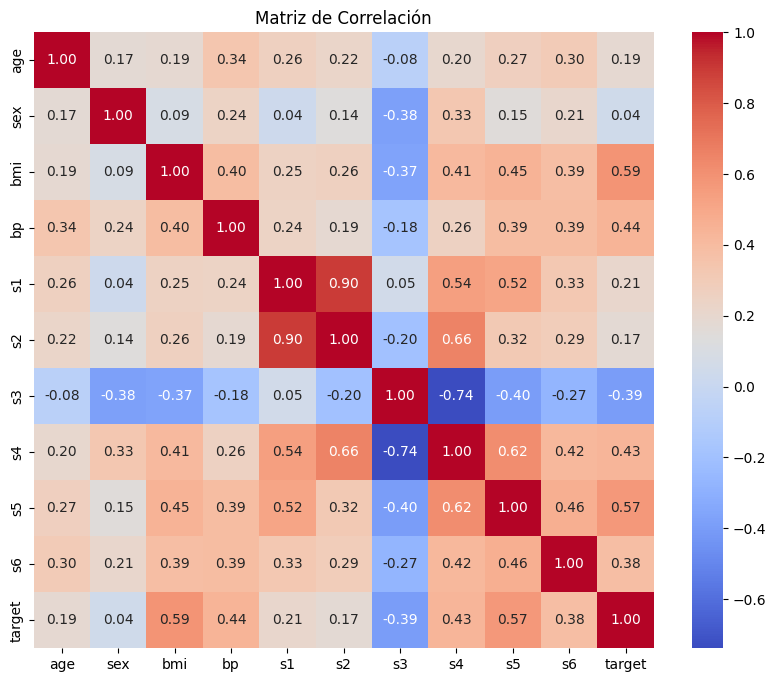


--- Variables más correlacionadas con el Target ---
target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64


In [2]:
# Estadísticos descriptivos
print(df.describe())

# Matriz de correlación
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Matriz de Correlación")
plt.show()

# Ranking de correlación con el target
print("\n--- Variables más correlacionadas con el Target ---")
print(corr_matrix['target'].sort_values(ascending=False))

# Visualización de Relaciones Clave
Basado en la matriz anterior, vemos que el **BMI** (Índice de Masa Corporal) tiene la correlación más alta.
A continuación, visualizamos la distribución del target y la relación específica entre BMI y el Target.

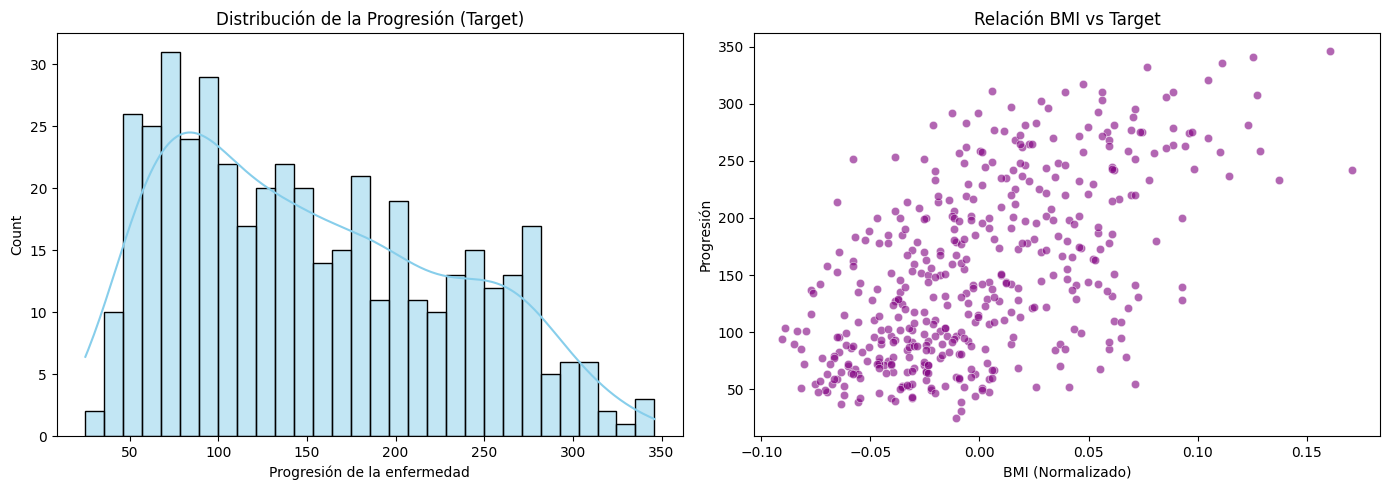

In [10]:
# Configuración de gráficos
plt.figure(figsize=(14, 5))

# Gráfico 1: Histograma del Target
plt.subplot(1, 2, 1)
sns.histplot(df['target'], kde=True, bins=30, color='skyblue')
plt.title("Distribución de la Progresión (Target)")
plt.xlabel("Progresión de la enfermedad")

# Gráfico 2: Scatter plot BMI vs Target
plt.subplot(1, 2, 2)
sns.scatterplot(x=df['bmi'], y=df['target'], alpha=0.6, color='purple')
plt.title("Relación BMI vs Target")
plt.xlabel("BMI (Normalizado)")
plt.ylabel("Progresión")

plt.tight_layout()
plt.show()

# 2. Preprocesamiento
Separamos las variables predictoras (X) de la variable objetivo (y).
Dividimos el dataset en conjuntos de entrenamiento (80%) y prueba (20%) para evaluar correctamente el modelo.

In [4]:
from sklearn.model_selection import train_test_split

# Definir X e y
X = df.drop('target', axis=1)
y = df['target']

# Dividir dataset: 80% Train, 20% Test
# random_state=42 asegura que el resultado sea reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_test: {X_test.shape}")

Tamaño de X_train: (353, 10)
Tamaño de X_test: (89, 10)


# 3. Entrenamiento del Modelo de Regresión Lineal
Entrenamos el modelo utilizando únicamente los datos de entrenamiento.
Luego, extraemos los coeficientes para interpretar qué peso asigna el modelo a cada variable.

In [5]:
from sklearn.linear_model import LinearRegression

# Instanciar y entrenar
model = LinearRegression()
model.fit(X_train, y_train)

# Mostrar coeficientes
coef_df = pd.DataFrame({'Variable': X.columns, 'Coeficiente': model.coef_})
coef_df = coef_df.sort_values(by='Coeficiente', ascending=False)

print("Intercepto (b0):", model.intercept_)
print("\nCoeficientes ordenados:")
print(coef_df)

Intercepto (b0): 151.34560453985995

Coeficientes ordenados:
  Variable  Coeficiente
8       s5   736.198859
2      bmi   542.428759
5       s2   518.062277
3       bp   347.703844
7       s4   275.317902
6       s3   163.419983
9       s6    48.670657
0      age    37.904021
1      sex  -241.964362
4       s1  -931.488846


# 4. Evaluación del Modelo
Realizamos predicciones sobre el conjunto de prueba y calculamos las métricas de error:
- **MSE:** Error cuadrático medio.
- **RMSE:** Raíz del error cuadrático medio (en las mismas unidades que el target).
- **MAE:** Error absoluto medio.
- **R²:** Coeficiente de determinación (qué tanto explica el modelo la varianza de los datos).

In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predecir sobre el conjunto de prueba
y_pred = model.predict(X_test)

# Calcular métricas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.4f}")

MSE: 2900.19
RMSE: 53.85
MAE: 42.79
R²: 0.4526


# 5. Visualización: Predicciones vs Realidad
Graficamos los valores reales frente a los predichos. La línea roja discontinua representa la predicción perfecta.

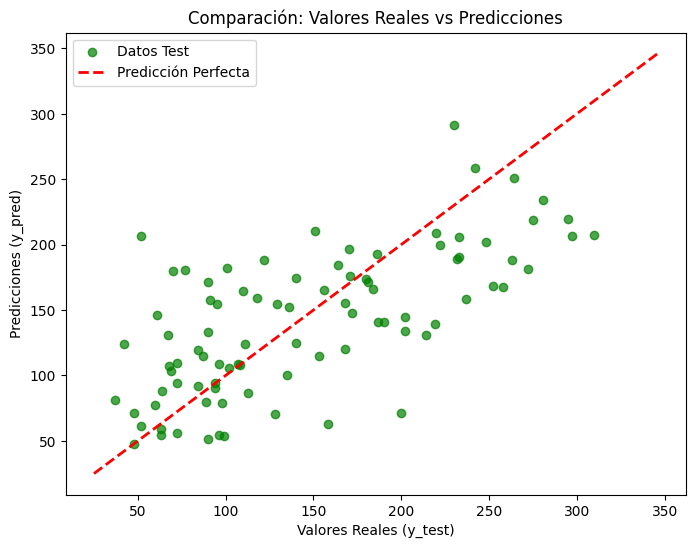

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='green', label='Datos Test')

# Línea de identidad perfecta (y = x)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Predicción Perfecta')

plt.xlabel("Valores Reales (y_test)")
plt.ylabel("Predicciones (y_pred)")
plt.title("Comparación: Valores Reales vs Predicciones")
plt.legend()
plt.show()

## Informe de Resultados y Conclusiones

### 1. Exploración de Datos
El dataset contiene 10 variables fisiológicas normalizadas. Al analizar la matriz de correlación, observamos que **BMI** (0.59) y **s5** (0.57) son las variables que tienen una relación lineal positiva más fuerte con la progresión de la enfermedad.

### 2. Entrenamiento e Interpretación
Al entrenar el modelo, los coeficientes revelaron que, en combinación con las otras variables:
* **s5 y BMI** tienen coeficientes positivos muy altos, confirmando su importancia como factores de riesgo.
* Se detectó una posible multicolinealidad entre **s1 y s2** (coeficientes opuestos muy grandes), lo que puede dificultar la interpretación individual de esas dos variables específicas.

### 3. Evaluación del Modelo
El modelo obtuvo un **R² de 0.45**, lo que indica que es capaz de explicar el 45% de la variabilidad en la progresión de la enfermedad.
* El **RMSE** es de aproximadamente 54, lo que significa que el error promedio de nuestras predicciones es de 54 puntos respecto al valor real.

### 4. Conclusión Visual
La gráfica de "Predicciones vs Valores Reales" muestra que el modelo captura la tendencia general (a mayor valor real, mayor predicción), pero existe una dispersión considerable. El modelo tiende a funcionar mejor en valores medios, pero pierde precisión en los extremos (valores muy bajos o muy altos), lo cual es consistente con un R² moderado.